[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/exorbyte/mbox-cookbook/blob/main/05-explainability/06-numeric_fields_explained.ipynb)

In [1]:
# !pip install mbox

# Numeric Fields Explained

`01-index_types_and_recall_modes.ipynb` showed that `INTEGER` and `DOUBLE` reuse the same four comparison engines as the string types, `NUM_APPROX` is `APPROX`, `NUM_GEQ` is `COMPLETE`, and so on, just reinterpreted for numbers. This notebook tests exactly what that reinterpretation means in practice, on `year_released` (`INTEGER`) and `price` (`DOUBLE`) from the catalog, and finds something worth knowing before you lean on it: numeric `APPROX` is a great deal stricter than string `APPROX`, and it is not equally strict on both numeric types.

In this notebook you will:

1. Discover that `APPROX` on this `INTEGER` field currently tolerates no distance at all, it behaves like `EXACT`
2. Confirm `APPROX` on the `DOUBLE` field does tolerate a small window, real, but narrow
3. Confirm `NUM_EXACT` behaves exactly like its string counterpart, on both numeric types
4. See that `NUM_GEQ` and `NUM_LEQ` are hard, one-sided filters, a candidate either clears the threshold or it does not, there is no partial credit
5. Walk away with practical guidance for numeric fields, and what not to assume about `APPROX` going in

In [2]:
import pandas as pd
from mbox.indexing import TableIndexer
from mbox.recall import TableRecallMode

catalog = pd.read_csv("datasets/product_catalog.csv")
index = TableIndexer.create_index(
    catalog,
    index_columns=["product_id", "product_name", "category", "year_released", "price"],
    tmp_dir="tmp_index"
)

catalog[["product_id", "year_released", "price"]]

,product_id,year_released,price
0,B88-EXT-24,2024,39.99
1,A12-PWR-22,2022,29.50
2,C99-SNS-23,2023,89.00
3,D45-REL-21,2021,24.99
4,E67-LEN-24,2024,149.99
5,F31-TRK-20,2020,59.00
6,G14-CAB-19,2019,12.99
7,H82-DOC-23,2023,74.50
8,I29-BAT-22,2022,9.99
9,J56-SEN-24,2024,44.00


`year_released` is `INTEGER`, values clustered in a six-year range. `price` is `DOUBLE`, values under two hundred. Both are searched with a small helper that isolates one target row's score as the query moves away from it, the numeric equivalent of the `substitute_n` helper used for strings in earlier notebooks.

In [3]:
def score_for(column, query, mode, target_value):
    result = index.match(**{column: query}, modes={column: mode}, include_field_scores=True, min_total_match_value=0, max_results=10)
    matching_row = result[result[f"{column}_candidate"] == target_value]
    return matching_row[f"{column}_score"].iloc[0] if len(matching_row) else None

## 1. `APPROX` on `year_released` (`INTEGER`): no room at all

`"D45-REL-21"` was released in `2021`. Query nearby years and see how far the match tolerates.

In [4]:
rows = []
for query_year in [2021, 2015, 2010, 1990, 1980]:
    rows.append({
        "query": query_year,
        "distance": 2021 - query_year,
        "year_released_score": score_for("year_released", query_year, TableRecallMode.APPROX, 2021)
    })

pd.DataFrame(rows)

,query,distance,year_released_score
0,2021,0,100.0
1,2015,6,NaN
2,2010,11,NaN
3,1990,31,NaN
4,1980,41,NaN


Only `distance=0` scores anything at all, every other row comes back `None`, not a low score, no candidate. `APPROX` on this field is not behaving like the typo-tolerant matching you have seen everywhere else in this cookbook, it is behaving like `EXACT`.

Before trusting that, rule out the obvious alternative explanation: the catalog's other real rows all sit in `2019`-`2024`, close enough to `2021` that a "nearby" query might just be landing on a *different* real row instead of decaying away from this one. Build a single-row index, just this one value, with nothing nearby to compete with, and query it directly at several distances and two very different magnitudes.

In [5]:
from mbox.config import TableConfig, TableFieldConfig, IndexType

def build_single_column_index(column, value, index_type):
    df = pd.DataFrame({column: [value]})
    config = TableConfig(fields=[TableFieldConfig(column=column, index_type=index_type)])
    return TableIndexer.create_index(df=df, config_overrides=config, tmp_dir="tmp_index")

def isolated_score(idx, column, query):
    result = idx.match(**{column: query}, modes={column: TableRecallMode.APPROX}, include_field_scores=True, min_total_match_value=0, max_results=1)
    found = len(result) > 0 and result["index_row"].iloc[0] != -1
    return result[f"{column}_score"].iloc[0] if found else None

small_target_index = build_single_column_index("year_released", 2021, IndexType.INTEGER)
large_target_index = build_single_column_index("year_released", 123456, IndexType.INTEGER)

print("Isolated, small magnitude (target 2021):")
for d in [0, 1, 5, 41, 90]:
    print(f"  distance={d:3d}  query={2021 - d:>7}  -> {isolated_score(small_target_index, 'year_released', 2021 - d)}")

print("Isolated, large magnitude (target 123456):")
for q in [123456, 123457, 999999]:
    print(f"  query={q}  -> {isolated_score(large_target_index, 'year_released', q)}")

config_overrides is given, therefore all information from index_columns, index_types, alias_sets and character_mappings is ignored.
config_overrides is given, therefore all information from index_columns, index_types, alias_sets and character_mappings is ignored.
Isolated, small magnitude (target 2021):
  distance=  0  query=   2021  -> 100
  distance=  1  query=   2020  -> None
  distance=  5  query=   2016  -> None
  distance= 41  query=   1980  -> None
  distance= 90  query=   1931  -> None
Isolated, large magnitude (target 123456):
  query=123456  -> 100
  query=123457  -> None
  query=999999  -> None


Same result with zero competition from other rows, and it does not matter whether the number is a four-digit year or a six-digit code: `APPROX` on `IndexType.INTEGER` currently only matches the exact value. This is not an artifact of this particular catalog, it is the field type's real, current default behavior, and it is worth knowing before you index a quantity or a year expecting the same graceful typo-style tolerance `PHRASE`, `TERM`, and `IDENT` give you.

## 2. `APPROX` on `price` (`DOUBLE`): a little room, but not much

Run the identical style of test on `price`, `"B88-EXT-24"` costs `39.99`.

In [6]:
price_rows = []
for query_price in [39.99, 39.5, 39.0, 38.0, 35.0, 30.0]:
    price_rows.append({
        "query": query_price,
        "distance": round(39.99 - query_price, 2),
        "price_score": score_for("price", query_price, TableRecallMode.APPROX, 39.99)
    })

pd.DataFrame(price_rows)

,query,distance,price_score
0,39.99,0.00,100.0
1,39.50,0.49,50.0
2,39.00,0.99,NaN
3,38.00,1.99,NaN
4,35.00,4.99,NaN
5,30.00,9.99,NaN


Unlike `year_released`, `price` does tolerate *something*: `39.50`, fifty cents off, still scores `50`. But the match is gone entirely by `39.00`, a distance of under a dollar. `DOUBLE` is not strict in quite the same all-or-nothing way `INTEGER` just was, but "a little tolerance" is doing a lot of work in that sentence, do not mistake it for "roughly nearby." Chart both fields' actual tolerance windows to see the shapes side by side.

config_overrides is given, therefore all information from index_columns, index_types, alias_sets and character_mappings is ignored.
config_overrides is given, therefore all information from index_columns, index_types, alias_sets and character_mappings is ignored.


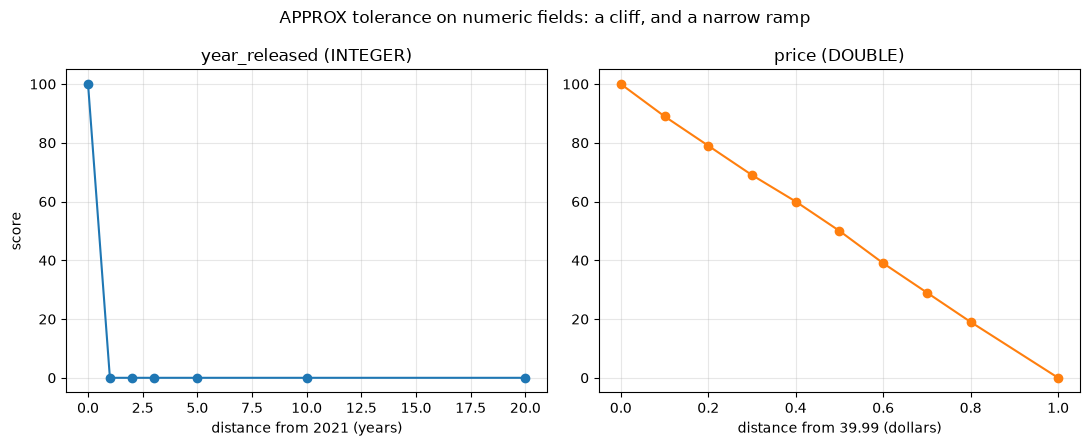

In [7]:
import matplotlib.pyplot as plt

year_distances = [0, 1, 2, 3, 5, 10, 20]
price_distances = [round(d, 2) for d in [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]]

isolated_year_index = build_single_column_index("year_released", 2021, IndexType.INTEGER)
isolated_price_index = build_single_column_index("price", 39.99, IndexType.DOUBLE)

year_scores = [isolated_score(isolated_year_index, "year_released", 2021 - d) or 0 for d in year_distances]
price_scores = [isolated_score(isolated_price_index, "price", round(39.99 - d, 2)) or 0 for d in price_distances]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(year_distances, year_scores, marker="o", color="tab:blue")
ax1.set_title("year_released (INTEGER)")
ax1.set_xlabel("distance from 2021 (years)")
ax1.set_ylabel("score")
ax1.set_ylim(-5, 105)
ax1.grid(True, alpha=0.3)

ax2.plot(price_distances, price_scores, marker="o", color="tab:orange")
ax2.set_title("price (DOUBLE)")
ax2.set_xlabel("distance from 39.99 (dollars)")
ax2.set_ylim(-5, 105)
ax2.grid(True, alpha=0.3)

fig.suptitle("APPROX tolerance on numeric fields: a cliff, and a narrow ramp")
plt.tight_layout()
plt.show()

`year_released` drops straight to `0` the instant the query isn't exact, a cliff, not a curve. `price` has an actual ramp, but it's over within about a dollar. Neither of these is the wide, forgiving tolerance `APPROX` gives a `PHRASE` or `TERM` field. **Do not assume `NUM_APPROX` will find "roughly nearby" numeric values the way `APPROX` finds "roughly similar" text.** On `INTEGER`, currently, it will not find anything except the exact value. On `DOUBLE`, it will find values within about a dollar of an everyday-sized price, and that window does not scale with the size of your numbers, a `DOUBLE` field holding values in the thousands would show the same sub-`1.0` window `price` just did.

## 3. `NUM_EXACT`: strict numeric equality

No surprises here, `NUM_EXACT` is `EXACT` applied to numbers: a full match scores `100`; any other query for that same target value simply will not bring it back as a candidate, on both `INTEGER` and `DOUBLE`.

In [8]:
print("year_released, NUM_EXACT:")
for q in [2021, 2020, 2022]:
    print(f"  {q} -> {score_for('year_released', q, TableRecallMode.NUM_EXACT, 2021)}")

print("price, NUM_EXACT:")
for q in [39.99, 39.98, 40.00]:
    print(f"  {q} -> {score_for('price', q, TableRecallMode.NUM_EXACT, 39.99)}")

year_released, NUM_EXACT:
  2021 -> 100
  2020 -> None
  2022 -> None
price, NUM_EXACT:
  39.99 -> 100
  39.98 -> None
  40.0 -> None


After Sections 1 and 2, this is almost an anticlimax, `NUM_EXACT` behaves exactly as documented, and, on `INTEGER`, it behaves identically to what `APPROX` already turned out to do by default.

## 4. `NUM_GEQ` and `NUM_LEQ`: hard, one-sided filters

`NUM_GEQ` matches when the indexed value is greater than or equal to your query value, `NUM_LEQ` is the mirror image, lower than or equal to. Both are one-sided thresholds, not proximity scores, a candidate on the correct side scores a flat `100`, and a candidate on the wrong side is not returned at all, not even with a low score.

In [9]:
rows = []
for query_year in [2000, 2015, 2020, 2021, 2022, 2025, 2050]:
    rows.append({
        "query": query_year,
        "NUM_GEQ (year >= query)": score_for("year_released", query_year, TableRecallMode.NUM_GEQ, 2021),
        "NUM_LEQ (year <= query)": score_for("year_released", query_year, TableRecallMode.NUM_LEQ, 2021),
    })

pd.DataFrame(rows)

,query,NUM_GEQ (year >= query),NUM_LEQ (year <= query)
0,2000,100.0,NaN
1,2015,100.0,NaN
2,2020,100.0,NaN
3,2021,100.0,100.0
4,2022,NaN,100.0
5,2025,NaN,100.0
6,2050,NaN,100.0


At `query=2021`, the target year itself, both modes score `100`, the boundary counts as satisfying both directions, that is exactly what the "or equal" in each name promises. Move the query above `2021` and `NUM_GEQ` drops out entirely, `2021` is no longer greater than or equal to a query that has moved past it, there is no partial credit on the way out. `NUM_LEQ` does the same thing in the opposite direction.

This is a real, useful distinction from Sections 1 and 2: `NUM_GEQ`/`NUM_LEQ` are deliberately strict, and that strictness is the point, "products released in or after 2022" should not quietly include `2021` at a discount. If what you actually want is a ranked sense of "how close is this candidate to satisfying a greater-than-or-less-than constraint," that is not what these modes give you here, pair `min_qualities` or `minimum_quality` in a `TableRecallConfig` with the threshold you actually need, covered in `04-recall-tuning/02-weighting_fields_for_better_precision.ipynb`, rather than assuming either mode will rank a near miss above a distant one.

## Practical notes

**Don't expect `APPROX` on a numeric field to behave like `APPROX` on text.** On this `INTEGER` field it currently finds the exact value only, full stop. On this `DOUBLE` field it finds values within roughly a dollar of an everyday-sized price. Neither is the forgiving, typo-tolerant `APPROX` you have relied on for `PHRASE`, `TERM`, and `IDENT` fields everywhere else in this cookbook, verify the actual tolerance on your own data before depending on it.

**`INTEGER` and `DOUBLE` are not interchangeable just because both are numeric.** If you need any fuzziness at all on a whole-number field, a `DOUBLE` may currently serve you better than an `INTEGER`, or you may need to build the "nearby" logic yourself, filtering with pandas before or after the match, rather than trusting `NUM_APPROX` to do it.

**`NUM_GEQ` and `NUM_LEQ` are boundaries, not rankings.** A candidate either clears the threshold or it doesn't, there's no smooth handoff at the edge. If a query needs "products released after 2021, but a 2021 release is still worth showing, just ranked lower," that's a job for `minimum_quality` and weighting, not for the mode alone.

**Isolate a field before trusting a tolerance measurement.** Section 1's single-row index was what actually proved the zero-tolerance finding wasn't just `year_released` losing a popularity contest to a nearby real row in the catalog. Whenever a numeric tolerance result looks surprising, rule out interference from other real values in the same index before concluding it's the mode's real behavior.

**Numeric mode behavior can change between SDK releases, verify it on the version you actually run.** Every score on this page came from actually running the query, not from the docs description alone, `04-recall-tuning/03-numeric_matching_ranges_and_thresholds.ipynb` has more on how these modes are named and versioned.

## Next steps

- **`07-multi_field_weights_explained.ipynb`** - combining `PHRASE`, `TERM`, `IDENT`, and numeric fields into one `overall_score`
- **`08-debugging_a_bad_match.ipynb`** - a real, multi-cause debugging walkthrough that draws on everything in this directory

*M|BOX is currently in `beta`. Breaking changes may occur in minor releases until version `1.0.0`.*